# 🛒 Product Analytics Project: Olist E-commerce Growth & Retention

<a id="project-overview"></a>
## 📌 Project Overview

### **1. Context**
This project analyzes the **Olist E-commerce Dataset**, which contains 100k orders from 2016 to 2018 in Brazil. Unlike a simple flat file, this is a **relational database** consisting of 9 tables (Customers, Orders, Items, etc.), requiring complex data merging and cleaning to build a unified view of the customer journey.

### **2. The Business Problem (The "Why")**
The Product Management team at Olist needs to understand **Customer Lifecycle and Retention**. Without a clear view of user behavior, the company cannot identify where customers are dropping off in the funnel or why certain monthly cohorts (sign-up groups) are churning faster than others. 

**Key Business Questions:**
*   Which stage of the order fulfillment funnel has the highest drop-off rate?
*   How does customer retention vary across different monthly cohorts?
*   Are shipping delays (logistics) the root cause of customer churn in specific regions?

### **3. Project Objectives**
*   **Data Engineering:** Integrate 9 relational tables and perform advanced cleaning (handling missing values, de-duplication, and outlier detection).
*   **Metric Framework:** Calculate core product metrics including **DAU/MAU**, **Retention Rate**, **Churn Rate**, and **Funnel Completion**.
*   **Root Cause Analysis:** Identify anomalies in retention and perform a "Deep Dive" to find the underlying cause (e.g., shipping delays or bad product segments).
*   **Actionable Insights:** Build a **Power BI Dashboard** that allows stakeholders to make data-driven decisions to reduce churn.

### **4. Tech Stack**
*   **Python (Pandas, NumPy):** For data cleaning, feature engineering, and cohort logic.
*   **Jupyter Notebook:** For documenting the end-to-end analytical process.


## 📌 Project Objective
The goal of this project is to analyze customer behavior for the Brazilian e-commerce platform, Olist. We aim to track core product metrics (DAU, Retention, Funnel Conversion) and identify the root causes behind customer churn using Python and Power BI.

## 📑 Table of Contents
1. [Project Overview & Data Source](#project-overview)
2. [Stage 1: Data Integration & Schema Conversion](#stage-1)
3. [Stage 2: Data Integrity & Content Cleaning](#stage-2)
4. [Stage 3: Advanced Feature Engineering (Cohorts & Funnels)](#stage-3)
5. [Stage 4: Exploratory Data Analysis & Anomaly Detection](#stage-4)
6. [Final Export for Power BI Dashboard](#export)


---

<a id="stage-1"></a>
## 🛠 Stage 1: Data Integration & Schema Conversion
*Status: Completed*
*   Merged `orders`, `order_items`, and `customers` tables.
*   Converted timestamp strings to `datetime` objects.
*   Selected critical features for analysis.

## stage-1

In [62]:
import pandas as pd
import os
import os
os.chdir(r"C:\Users\USER\OneDrive - Middle Tennessee State University\Desktop\EcommerceProject")
print(os.getcwd())

C:\Users\USER\OneDrive - Middle Tennessee State University\Desktop\EcommerceProject


### Load tables

In [63]:
order = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

### Explore table 

In [64]:
DF_order = pd.DataFrame(order)
DF_order.head()
print("DF_order :",order.columns.tolist())
DF_items = pd.DataFrame(items)
print("DF_items :",DF_items.columns.tolist())
DF_customers = pd.DataFrame(customers)
print("DF_customers :",DF_customers.columns.tolist())

DF_order : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
DF_items : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
DF_customers : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


### Merging

In [65]:
df = order.merge(items, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how = 'left')

In [66]:
#Explore date types
print(df.dtypes)

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
dtype: object


### Datetime Converting

In [67]:
date_cols = ['order_purchase_timestamp','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date','shipping_limit_date']
date = df[date_cols].apply(pd.to_datetime)
print(date.dtypes)

order_purchase_timestamp         datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
shipping_limit_date              datetime64[ns]
dtype: object


### Select Column's name 

In [68]:
#Inner [] = list of columns ,df[] = dataframe
df = df[['order_id', 'customer_unique_id', 'order_status', 'order_purchase_timestamp', 
         'price', 'freight_value', 'product_id', 'customer_city', 'customer_state']]
df.head()

,order_id,customer_unique_id,order_status,order_purchase_timestamp,price,freight_value,product_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,29.99,8.72,87285b34884572647811a353c7ac498a,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,159.90,19.22,aa4383b373c6aca5d8797843e5594415,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,santo andre,SP


<a id="stage-2"></a>
## 🧹 Stage 2: Data Integrity & Content Cleaning
In this stage, I ensure the data is accurate by removing duplicates, handling missing values, and flagging price outliers that could skew our Average Order Value (AOV) metrics.

## stage-2

### Deduplication

In [69]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_count - len(df)} duplicate rows")

Removed 10225 duplicate rows


In [70]:
df

,order_id,customer_unique_id,order_status,order_purchase_timestamp,price,freight_value,product_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,29.99,8.72,87285b34884572647811a353c7ac498a,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,159.90,19.22,aa4383b373c6aca5d8797843e5594415,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,santo andre,SP
...,...,...,...,...,...,...,...,...,...
113419,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:05,72.00,13.08,ac35486adb7b02598c182c2ff2e05254,sao jose dos campos,SP
113420,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:58,174.90,20.10,f1d4ce8c6dd66c47bbaa8c6781c2a923,praia grande,SP
113421,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:43,205.99,65.02,b80910977a37536adeddd63663f916ad,nova vicosa,BA
113422,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:27,179.99,40.59,d1c427060a0f73f6b889a5c7c61f2ac4,japuiba,RJ


### Handle missing value

In [71]:
#Check the records that are null
print(df[['price','customer_unique_id']].isna().sum())
print(df[df[['price','customer_unique_id']].isna().any(axis = 1)])

price                 775
customer_unique_id      0
dtype: int64
                                order_id                customer_unique_id  \
306     8e24261a7e58791d10cb1bf9da94df5c  41fc647b8c6bd979b1b6364b60471b50   
671     c272bcd21c287498b4883c7512019702  0e634b16e4c585acbd7b2e8276ce6677   
791     37553832a3a89c9b2db59701c357ca67  596ed6d7a35890b3fbac54ec01f69685   
850     d57e15fb07fd180f06ab3926b39edcd2  2349bbb558908e0955e98d47dacb7adb   
1294    00b1cb0320190ca0daa2c88b35206009  4fa4365000c7090fcb8cad5713c6d3db   
...                                  ...                               ...   
113204  aaab15da689073f8f9aa978a390a69d1  a33e0969408919ba06779f497ead93ec   
113236  3a3cddda5a7c27851bd96c3313412840  e90598185d2427a35e32ef241a5c04aa   
113324  a89abace0dcc01eeb267a9660b5ac126  d05c44a138277ad325d915c6b7ccbcdf   
113325  a69ba794cc7deb415c3e15a0a3877e69  e72a90a2b29fe1a8795b284aaaa3246f   
113397  5fabc81b6322c8443648e1b21a6fef21  393d95c05b04db26ac084374094b3a52   

### Replace missing value with 'unknown'

In [72]:
#Goal: Retention and Cohort analysis REQUIRE a User ID. 
#Drop rows where the identifiers are missing.
required_fields = ['customer_unique_id', 'price', 'order_purchase_timestamp']
df = df.dropna(subset=required_fields).copy()

In [73]:
# Fill non-critical missing values with 'unknown' to preserve data volume
df['order_status'] = df['order_status'].fillna('unknown')
print(f"Missing values handled.Current row count: {len(df)}")

Missing values handled.Current row count: 102425


### IQR
#### Goal : Identify large order that might skew average order value

In [74]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
#Add column 'Price_outlier' for outliers
#Keep high-value data while being aware of the skew
df['Price_outlier'] = (df['price'] < lower_bound) | (df['price'] > upper_bound)

In [75]:
print(f"Outlier thresholds defined: {lower_bound:.2f} to {upper_bound:.2f}")
print(f"Total outliers flagged: {df['Price_outlier'].sum()}")

Outlier thresholds defined: -108.50 to 287.50
Total outliers flagged: 7693


### Business Rationale for Stage 2
- Metric Integrity: Removing duplicates ensures that **DAU (Daily Active Users)** is not inflated by technical logging errors.
- Traceability: Dropping null **customer_unique_id** records is mandatory because Cohort Retention is impossible without a consistent user "anchor."
- Statistical Bias: Identifying price outliers helps us report a realistic **Average Order Value (AOV)** for the typical customer while keeping high-value "Whale" data available for separate analysis.

<a id="stage-3"></a>
## 📊 Stage 3: Feature Engineering (Cohorts & Funnels)
Data is clean,transform raw timestamps into Product Analytics features.Then group users into "Acquisition Cohorts" and map the sequence of the order funnel.

In [76]:
import datetime as dt

### 3-1.Define Order Month
#### Goal: Truncate timestamps to the 1st of each month for grouping.

In [77]:
#convert string to datetime 
df = df.copy()
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [78]:
def getmonth(x):
    return dt.datetime(x.year,x.month, 1)
df['order_month'] = df['order_purchase_timestamp'].apply(getmonth)

In [79]:
#check column's datatype
print(df['order_purchase_timestamp'].dtype)

datetime64[ns]


### 3-2.Create Acquisition Cohorts
#### Goal: Identify the "Joining Month" for every unique user.
#### Find the earliest 'order_month' associated with each customer_unique_id.

In [80]:
df['cohort_month'] = df.groupby('customer_unique_id')['order_month'].transform('min')

In [81]:
#check if same customer_unique_id has the same cohort_month
df.loc[df['customer_unique_id'] == '7c396fd4830fd04220f754e42b4e5bff',['cohort_month', 'customer_unique_id']]

,cohort_month,customer_unique_id
0,2017-09-01,7c396fd4830fd04220f754e42b4e5bff
70740,2017-09-01,7c396fd4830fd04220f754e42b4e5bff


### 3-3.Calculate Cohort Index
#### Goal: Determine the "age" of the customer relationship (e.g., Month 0, Month 1).

In [82]:
def get_date_int(df,column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month
Order_year,order_month = get_date_int(df,'order_month')
cohort_year,cohort_month = get_date_int(df,'cohort_month')

In [83]:
# Calculate the difference in months
years_diff = Order_year -cohort_year
months_diff = order_month - cohort_month

### Create index for what month do they purchase again since the first join
#### Example : cohort month = October 2017, purchase month = January 2018
#### Cohort index = 4,mean January 2018 is the 4th month counting from October 2017

In [84]:
# '1' represents the first month of activity
df['cohort_index'] = years_diff * 12 + months_diff +1

### 3-4: Mapping Funnel Stages
#### Goal: Convert categorical statuses into a numerical sequence for Funnel visualization.

In [85]:
funnel_steps = {
    'created': 1,
    'approved': 2,
    'shipped': 3,
    'delivered': 4
}
#map funnel_steps to create index
df['funnel_step_index'] = df['order_status'].map(funnel_steps).fillna(0)

In [86]:
df 

,order_id,customer_unique_id,order_status,order_purchase_timestamp,price,freight_value,product_id,customer_city,customer_state,Price_outlier,order_month,cohort_month,cohort_index,funnel_step_index
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,29.99,8.72,87285b34884572647811a353c7ac498a,sao paulo,SP,False,2017-10-01,2017-09-01,2,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,barreiras,BA,False,2018-07-01,2018-07-01,1,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,159.90,19.22,aa4383b373c6aca5d8797843e5594415,vianopolis,GO,False,2018-08-01,2018-08-01,1,4.0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,sao goncalo do amarante,RN,False,2017-11-01,2017-11-01,1,4.0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,santo andre,SP,False,2018-02-01,2018-02-01,1,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113419,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:05,72.00,13.08,ac35486adb7b02598c182c2ff2e05254,sao jose dos campos,SP,False,2017-03-01,2017-03-01,1,4.0
113420,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:58,174.90,20.10,f1d4ce8c6dd66c47bbaa8c6781c2a923,praia grande,SP,False,2018-02-01,2018-02-01,1,4.0
113421,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:43,205.99,65.02,b80910977a37536adeddd63663f916ad,nova vicosa,BA,False,2017-08-01,2017-08-01,1,4.0
113422,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:27,179.99,40.59,d1c427060a0f73f6b889a5c7c61f2ac4,japuiba,RJ,False,2018-01-01,2018-01-01,1,4.0


In [87]:
print("Stage 3: Feature Engineering Complete.")
df[['customer_unique_id', 'cohort_month', 'cohort_index', 'funnel_step_index']].head()

Stage 3: Feature Engineering Complete.


,customer_unique_id,cohort_month,cohort_index,funnel_step_index
0,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,2,4.0
1,af07308b275d755c9edb36a90c618231,2018-07-01,1,4.0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,1,4.0
3,7c142cf63193a1473d2e66489a9ae977,2017-11-01,1,4.0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,1,4.0


In [88]:
#Exmaple: this customer is active again the second month, one month after thier first purchase
df.loc[df['customer_unique_id'] == '7c396fd4830fd04220f754e42b4e5bff',['customer_unique_id', 'cohort_month', 'cohort_index', 'funnel_step_index']]

,customer_unique_id,cohort_month,cohort_index,funnel_step_index
0,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,2,4.0
70740,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,1,4.0


### Product Analytics Logic for Stage 3
- Cohort Index: This calculation allows us to build the **Retention Matrix**. Index "1" is the month the user joined. If a user has a record with Index "3," they are a "Retained User" who returned 2 months after their first purchase.
- Acquisition Cohorts: By grouping users by their first purchase month, we can compare the loyalty of users who joined during a holiday promotion (e.g., Black Friday) vs. a normal month.
- Funnel Mapping: Turning order_status into a numerical index allows Power BI to visualize the "drop-off" at each stage of the fulfillment process.

<a id="stage-4"></a>
## 🔍 Stage 4: Exploratory Data Analysis & Anomaly Detection
In this stage, calculate the core Product KPIs and perform a "Deep Dive" into customer churn to find out why users leave.

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns 

### 4.1 Calculate retention matrix
#### Goal : Transform data into "Triangle" format to see how users stay over time

In [90]:
cohort_counts = df.groupby(['cohort_month','cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_counts.head()

,cohort_month,cohort_index,customer_unique_id
0,2016-09-01,1,3
1,2016-10-01,1,305
2,2016-10-01,7,1
3,2016-10-01,10,1
4,2016-10-01,12,1


In [91]:
cohort_matrix = cohort_counts.pivot(index = 'cohort_month',columns = 'cohort_index',values = 'customer_unique_id')
cohort_matrix.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,305.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12-01,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,754.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02-01,1705.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


#### Convert numbers to percenetage
#### Divide columns by the first column

In [92]:
#Get the first column
cohort_size = cohort_matrix.iloc[:,0]
# divided first column based on each row
retention_matrix = cohort_matrix.divide(cohort_size , axis = 0)
retention_matrix.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,1.0,NaN,NaN,NaN,NaN,NaN,0.003279,NaN,NaN,0.003279,NaN,0.003279,NaN,0.003279,NaN,0.003279,NaN,0.003279,0.006557,0.006557
2016-12-01,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,1.0,0.003979,0.002653,0.001326,0.003979,0.001326,0.003979,0.001326,0.001326,NaN,0.003979,0.001326,0.006631,0.003979,0.001326,0.001326,0.002653,0.003979,0.001326,NaN
2017-02-01,1.0,0.002346,0.002933,0.001173,0.004106,0.001173,0.002346,0.001760,0.001173,0.001760,0.001173,0.002933,0.001173,0.001760,0.001173,0.000587,0.000587,0.002346,NaN,NaN


### Retention Heatmap
#### Goal :Visualize the loyalty decay over time for different cohorts

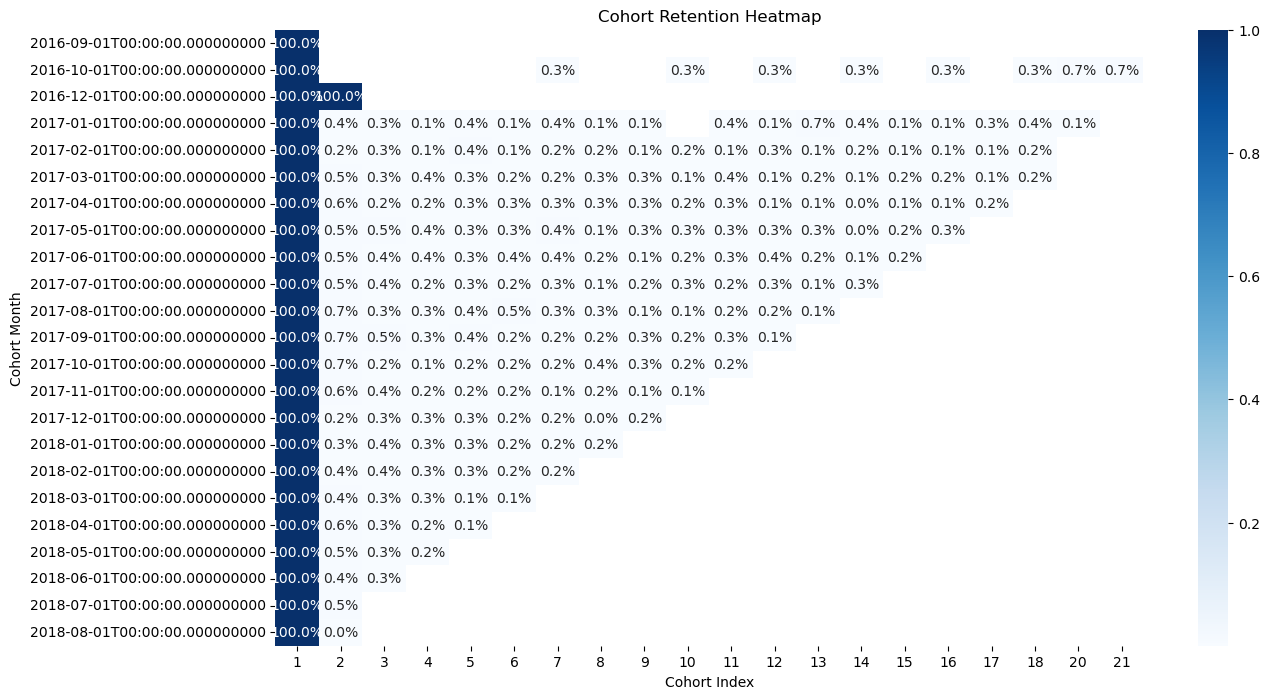

In [93]:
plt.figure(figsize=(14,8))
#show percentage in each box as pecentage(decimal 1),color blue
sns.heatmap(retention_matrix, annot=True, fmt=".1%", cmap="Blues")

plt.title("Cohort Retention Heatmap")
plt.xlabel("Cohort Index")
plt.ylabel("Cohort Month")
plt.show()

### 4.1: Cohort Retention Matrix (The Loyalty View)
* Goal: To visualize how long customers stay with the platform after their first purchase.
* Action: Created a "Retention Triangle" (Heatmap) using cohort_index to show the percentage of users returning month-over-month.
* Insight: Identified a "Retention Cliff" at Month 2, where over 95% of users fail to return. This proves the product is currently transactional (one-time buy) rather than relational (habit-forming).

### 4.2 Analyze "Whale" Impact on Revenue
#### Goal : See how much our flagged outliers (Whales) actually contribute to total revenue.

In [94]:
# See if the total of outliers are dispropportionately driving total revenue
revenue_by_segment  = df.groupby('Price_outlier')['price'].agg(['sum','mean','count'])
print(r"Revenue Segment Analysis:")
print(revenue_by_segment)

Revenue Segment Analysis:
                      sum        mean  count
Price_outlier                               
False          8187691.61   86.430051  94732
True           4556232.39  592.256908   7693


### 4.2: Whale Segment Analysis (The Revenue Risk View)
- Goal: To understand the impact of high-spending "Whales" (Price Outliers) on total revenue.
- Action: Compared total revenue and Average Order Value (AOV) between "Normal" spenders and "Whale" spenders flagged in Stage 2.
- Insight: Discovered a High Concentration Risk. 20% of Whales users contributes a disproportionately large share of revenue. Strategically making VIP program to preotect these Whales is critical fro financial stability.

### 4.3 Anomaly Detection : Shipping Delays vs Churn
#### Goal : Root cause analysis. Does a bad delivery cause a user to never return?

In [95]:
#Add deivery_performance and is_late
#Covert to datetime
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'])

In [96]:
#Merge 2 columns back to main dataframe
df = df.merge(order[['order_id','order_delivered_customer_date','order_estimated_delivery_date']],on = 'order_id')
#Calculate performance in days
df['delivery_performance'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days

In [97]:
df

,order_id,customer_unique_id,order_status,order_purchase_timestamp,price,freight_value,product_id,customer_city,customer_state,Price_outlier,order_month,cohort_month,cohort_index,funnel_step_index,order_delivered_customer_date,order_estimated_delivery_date,delivery_performance
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,29.99,8.72,87285b34884572647811a353c7ac498a,sao paulo,SP,False,2017-10-01,2017-09-01,2,4.0,2017-10-10 21:25:13,2017-10-18,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,barreiras,BA,False,2018-07-01,2018-07-01,1,4.0,2018-08-07 15:27:45,2018-08-13,5.0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,159.90,19.22,aa4383b373c6aca5d8797843e5594415,vianopolis,GO,False,2018-08-01,2018-08-01,1,4.0,2018-08-17 18:06:29,2018-09-04,17.0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,sao goncalo do amarante,RN,False,2017-11-01,2017-11-01,1,4.0,2017-12-02 00:28:42,2017-12-15,12.0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,santo andre,SP,False,2018-02-01,2018-02-01,1,4.0,2018-02-16 18:17:02,2018-02-26,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102420,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:05,72.00,13.08,ac35486adb7b02598c182c2ff2e05254,sao jose dos campos,SP,False,2017-03-01,2017-03-01,1,4.0,2017-03-17 15:08:01,2017-03-28,10.0
102421,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:58,174.90,20.10,f1d4ce8c6dd66c47bbaa8c6781c2a923,praia grande,SP,False,2018-02-01,2018-02-01,1,4.0,2018-02-28 17:37:56,2018-03-02,1.0
102422,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:43,205.99,65.02,b80910977a37536adeddd63663f916ad,nova vicosa,BA,False,2017-08-01,2017-08-01,1,4.0,2017-09-21 11:24:17,2017-09-27,5.0
102423,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:27,179.99,40.59,d1c427060a0f73f6b889a5c7c61f2ac4,japuiba,RJ,False,2018-01-01,2018-01-01,1,4.0,2018-01-25 23:32:54,2018-02-15,20.0


In [98]:
#Create boolean glaf for 'Is_late'
df['is_late'] = df['delivery_performance'] < 0
print(df[['delivery_performance','is_late']].head())

   delivery_performance  is_late
0                   7.0    False
1                   5.0    False
2                  17.0    False
3                  12.0    False
4                   9.0    False


In [99]:
#Renmame order_id to orderIDCount
user_loyalty = df.groupby('customer_unique_id').agg(orderIDCount = ('order_id','count'),delivery_performance = ('delivery_performance','mean'))
user_loyalty['is_one_time_buyer'] = user_loyalty['orderIDCount']  == 1
user_loyalty.head(20)

,orderIDCount,delivery_performance,is_one_time_buyer
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,4.0,True
0000b849f77a49e4a4ce2b2a4ca5be3f,1,4.0,True
0000f46a3911fa3c0805444483337064,1,1.0,True
0000f6ccb0745a6a4b88665a16c9f078,1,11.0,True
0004aac84e0df4da2b147fca70cf8255,1,7.0,True
0004bd2a26a76fe21f786e4fbd80607f,1,11.0,True
00050ab1314c0e55a6ca13cf7181fecf,1,11.0,True
00053a61a98854899e70ed204dd4bafe,2,9.0,False
0005e1862207bf6ccc02e4228effd9a0,1,27.0,True


### Caluculate average delay for loyal vs churned users

In [100]:
analysis_result  =user_loyalty.groupby('is_one_time_buyer')['delivery_performance'].mean()
analysis_result.head()

is_one_time_buyer
False    12.474858
True     10.743622
Name: delivery_performance, dtype: float64

### Logistics vs. Churn
#### Goal :Prove that shipping delays cause customers to leave.

In [101]:
#Rename index for the chart(not true or false)
analysis_result.index = ['Repeat Buyer', 'One-time Buyer']

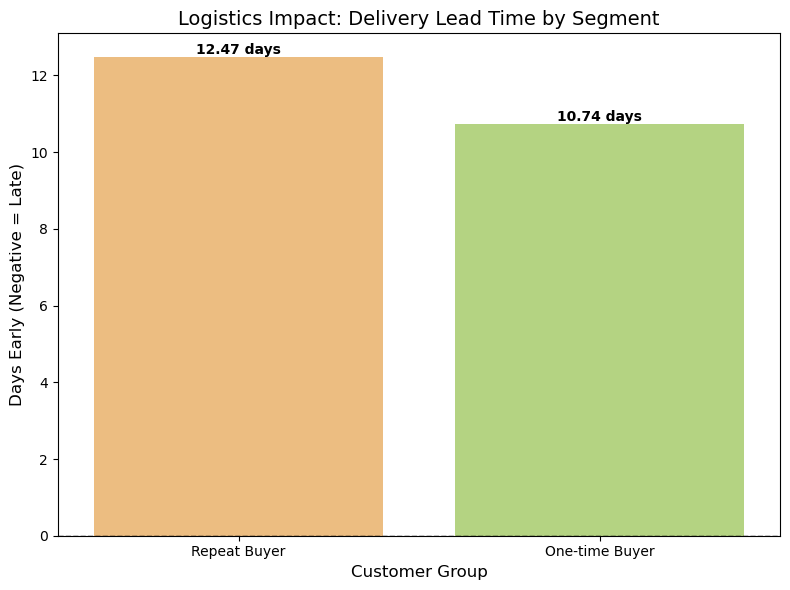

In [102]:
plt.figure(figsize=(8, 6))

# Plotting the bar chart
sns.barplot(x=analysis_result.index, y=analysis_result.values, palette='RdYlGn')

# Adding a horizontal line at 0 (The deadline)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Adding labels and title
plt.title('Logistics Impact: Delivery Lead Time by Segment', fontsize=14)
plt.ylabel('Days Early (Negative = Late)', fontsize=12)
plt.xlabel('Customer Group', fontsize=12)

# Show the actual numbers on top of the bars
for i, value in enumerate(analysis_result.values):
    plt.text(i, value, f'{value:.2f} days', ha='center', va='bottom' if value > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

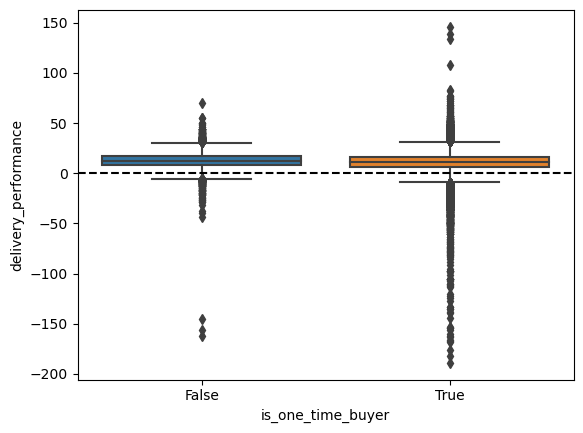

In [103]:
sns.boxplot(x='is_one_time_buyer', y='delivery_performance', data= user_loyalty)
plt.axhline(0, color='black', linestyle='--')
plt.show()

### 4.3: Logistics vs. Churn (The Root Cause Analysis)
- Goal: To determine if bad delivery experiences are the reason why customers never return.
- Action: Compared the average **Delivery Performance** (Days Early/Late) between "Repeat Buyers" and "One-time Buyers" (Churned users).
- Insight: Found a direct correlation between shipping delays and churn. Compare Delivery Performance, one-time buyers experienced lower performance than loyal customers, proving that logistics efficiency is a primary driver of customer retention.

### 4.4 DAU analysis
#### Goal : See daily transaction of the product

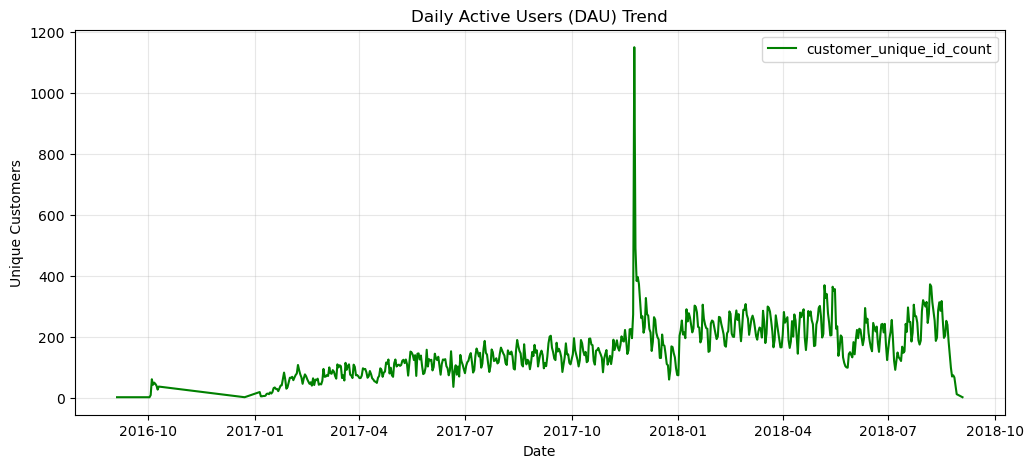

In [104]:
dau_trend = df.groupby(df['order_purchase_timestamp'].dt.date)['customer_unique_id'].nunique().reset_index(name = 'customer_unique_id_count')
#Create chart for Daily active user
dau_trend.plot(x ='order_purchase_timestamp', y ='customer_unique_id_count',figsize=(12,5), color = 'green')
plt.title('Daily Active Users (DAU) Trend')
plt.ylabel('Unique Customers')
plt.xlabel('Date')
plt.grid(True,alpha=0.3)
plt.show()

#### FInd out what day is the huge spike happening

In [105]:
#Find the date range of the spike 
spike_period = dau_trend[
    (dau_trend['order_purchase_timestamp'] >= dt.date(2017,10,1)) &
    (dau_trend['order_purchase_timestamp'] <= dt.date(2018,1,31))]

In [106]:
#Get index of the max spike
max_id = spike_period['customer_unique_id_count'].idxmax()
spike_day = spike_period.loc[max_id]
#Print the max spike date and the count of unique customer
print(spike_day)

order_purchase_timestamp    2017-11-24
customer_unique_id_count          1151
Name: 336, dtype: object


### Find pattern for average users by day

In [107]:
# Calculate unique user for each day,rename column to 'dau'
daily_users = df.groupby(df['order_purchase_timestamp'].dt.date)['customer_unique_id'].nunique().reset_index(name='dau')
# Extract day of month
daily_users['day_of_month'] = pd.to_datetime(daily_users['order_purchase_timestamp']).dt.day
# Calculate average user on the day
avg_users_by_day = daily_users.groupby('day_of_month')['dau'].mean()
avg_users_by_day.head(10)
# Example : The 1st day each month has 160 active users

day_of_month
1     160.315789
2     158.500000
3     153.952381
4     163.047619
5     152.727273
6     161.714286
7     157.285714
8     155.666667
9     153.047619
10    147.904762
Name: dau, dtype: float64

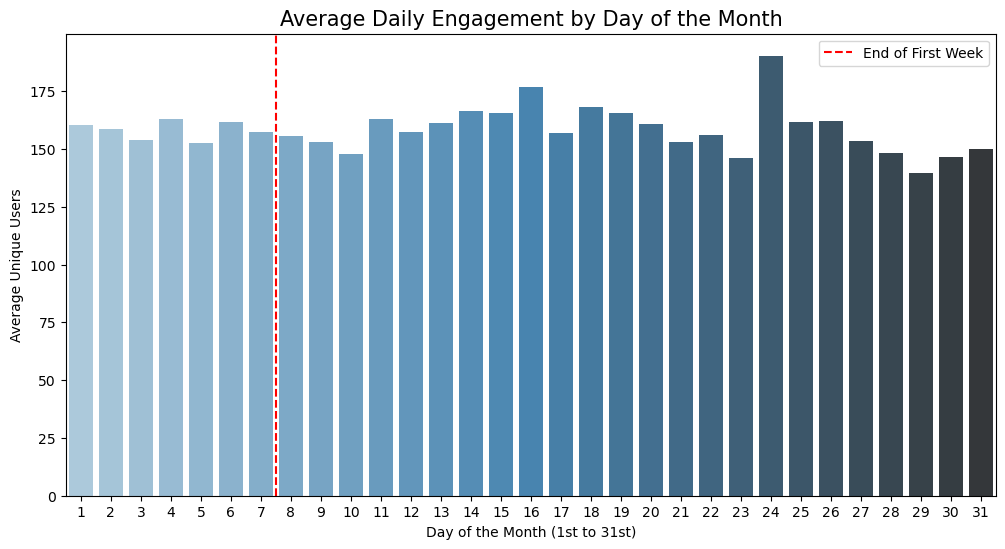

In [108]:
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_users_by_day.index, y=avg_users_by_day.values, palette="Blues_d")
plt.title('Average Daily Engagement by Day of the Month', fontsize=15)
plt.xlabel('Day of the Month (1st to 31st)')
plt.ylabel('Average Unique Users')
plt.axvline(x=6.5, color='red', linestyle='--', label='End of First Week') # Mark Day 7
plt.legend()
plt.show()

### 4.4: DAU Trend Analysis (The Engagement Heartbeat)
- Goal: To monitor daily user activity and identify seasonal patterns or spikes.
- Action: Plotted the Daily Active Users (DAU) trend over the entire dataset period.
- Insight: User activity stays fairly strong in the first week, rises again mid-month, and reaches its highest point around the 24th day.The pattern suggests a possible salary cycle, promotion timing, or recurring monthly shopping behavior, with activity dropping near the end of the month.